[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfelipevasquez/Forecasting-electricity-production-Kaggle/blob/main/03_Model_RandomForest.ipynb)

# Modeling with Random Forest

Next, the best parameters—determined through exploratory data analysis—will be applied.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings for academic reports and presentations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'figure.figsize': (14, 10),
    'axes.labelsize': 12,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

In [ ]:
# Automatically read the database provided for the problem
df = pd.read_csv("https://raw.githubusercontent.com/jfelipevasquez/Forecasting-electricity-production-Kaggle/refs/heads/main/dataset/train.csv")


In [ ]:
# Adjusting variable names (Friendly names)
friendly_names = {
    'kw': 'Energy Production (kW)', # Our Target Variable
    'capacity_clipped': 'Installed Capacity',
    'S_d': 'Direct Solar Radiation',
    'airmass': 'Air Mass',
    'altitude': 'Solar Altitude',
    'azimuth': 'Solar Azimuth',
    'irradiation': 'Irradiance',
    'fold_cos': 'Angular Factor (Fold)',
    'panel_cos': 'Angular Factor (Panel)',
    'rad_lw_mean': 'Longwave Radiation',
    'precip_total_mean': 'Precipitation (Rain)',
    'cloud_total_mean': 'Clouds (Total)',
    'temp_total_mean': 'Temperature',
    'cloud_high_mean': 'Clouds (High)',
    'rad_global_mean': 'Global Radiation',
    'cloud_low_mean': 'Clouds (Low)',
    'radNetS_lw_mean': 'Net Longwave Radiation',
    'cloud_mid_mean': 'Clouds (Mid)',
    'radNetS_sw_mean': 'Net Shortwave Radiation'
}

# Renaming dataframe columns for better readability
df = df.rename(columns=friendly_names)

First, the cyclical variables will be created.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def load_and_clean_data(df):
    # 1. DATA CLEANING AND IMPUTATION
    if 'start' in df.columns:
        df['start'] = pd.to_datetime(df['start'])
        df = df.sort_values(by='start').set_index('start')

    # Interpolation for state variables
    state_columns = [col for col in df.columns if col != 'Precipitation (Rain)' and col != 'Energy Production (kW)' and pd.api.types.is_numeric_dtype(df[col])]
    if state_columns:
        df[state_columns] = df[state_columns].interpolate(method='linear', limit_direction='both')

    # Seasonal Imputation for Rain
    if 'Precipitation (Rain)' in df.columns and df['Precipitation (Rain)'].isnull().sum() > 0:
        df['aux_month'] = df.index.month
        df['aux_hour'] = df.index.hour
        # Corrected: Added missing closing parenthesis here
        rain_profile = df.groupby(['aux_month', 'aux_hour'])['Precipitation (Rain)'].transform('mean')
        df['Precipitation (Rain)'] = df['Precipitation (Rain)'].fillna(rain_profile).fillna(0.0)
        df = df.drop(columns=['aux_month', 'aux_hour'])

    # Remove rows where the target is null
    if 'Energy Production (kW)' in df.columns:
        df = df.dropna(subset=['Energy Production (kW)'])

    df = df.reset_index()
    return df


Variables used in training (13 in total):
['Solar Altitude', 'Angular Factor (Fold)', 'Angular Factor (Panel)', 'Longwave Radiation', 'Temperature', 'Net Longwave Radiation', 'Net Shortwave Radiation', 'Irradiance', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'is_dia']

Training Data: 18772 hours (past)
Validation Data: 4693 hours (future)

Training the Random Forest model... (Please wait)

RESULT: Random Forest MAE = 20.36 kW


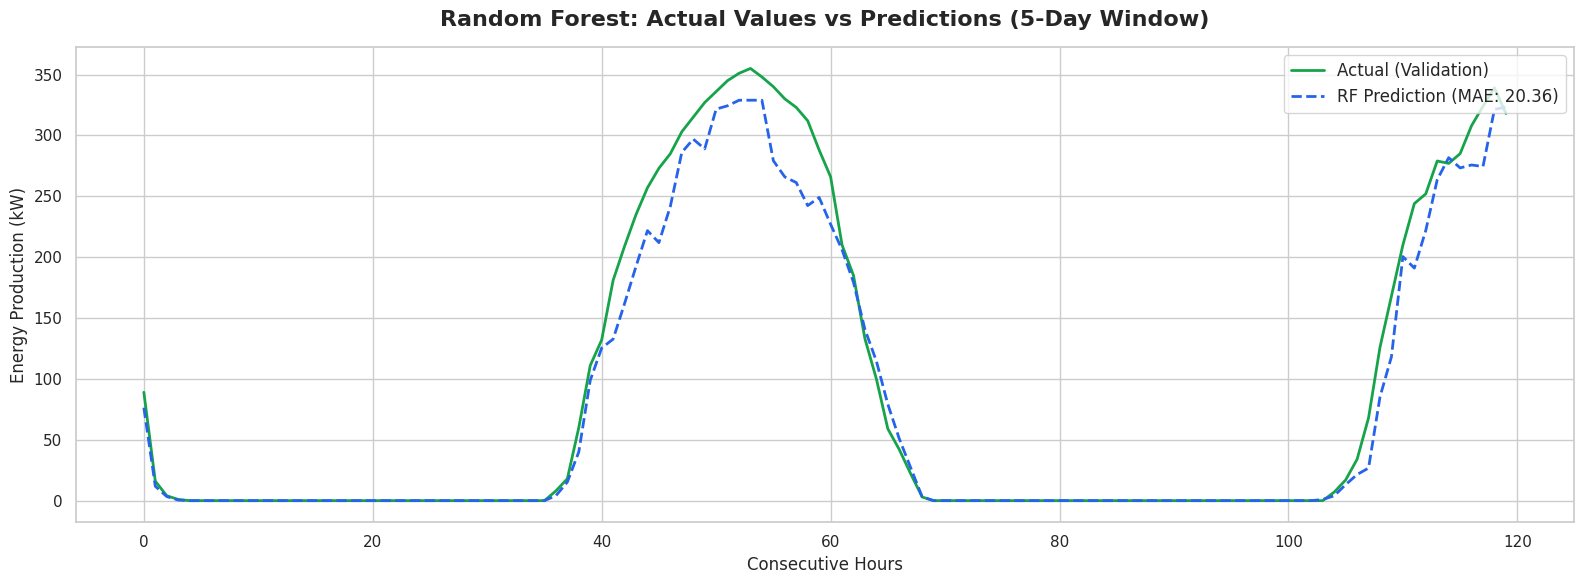


--- What did the Random Forest consider most important? ---
Irradiance                0.697101
Angular Factor (Panel)    0.068958
Temperature               0.050454
Net Longwave Radiation    0.049175
Longwave Radiation        0.041803
dtype: float64


In [ ]:
# 2: RANDOM FOREST MODELING

# Define data URL
data_url = "https://raw.githubusercontent.com/jfelipevasquez/Forecasting-electricity-production-Kaggle/refs/heads/main/dataset/train.csv"

# Load the initial raw DataFrame
raw_df = pd.read_csv(data_url)

# Apply friendly names to the raw DataFrame (assuming 'friendly_names' is defined globally)
df_renamed = raw_df.rename(columns=friendly_names)

# Now, call the cleaning function with the renamed DataFrame
df = load_and_clean_data(df_renamed.copy())

# 2.1. TEMPORAL FEATURE ENGINEERING (Cyclical Clock)
hour = df['start'].dt.hour
month = df['start'].dt.month

df['hora_sin'] = np.sin(2 * np.pi * hour / 24)
df['hora_cos'] = np.cos(2 * np.pi * hour / 24)
df['mes_sin'] = np.sin(2 * np.pi * month / 12)
df['mes_cos'] = np.cos(2 * np.pi * month / 12)

# Day/Night Flag
if 'Solar Altitude' in df.columns:
    df['is_dia'] = (df['Solar Altitude'] > 0).astype(int)
else:
    df['is_dia'] = ((hour >= 6) & (hour <= 18)).astype(int)

# 2.2. DEFINITION OF X (Features) and y (Target)
target_variable = 'Energy Production (kW)'

# Using the specific parameters found in the Exploratory Data Analysis
selected_features = [
    'Solar Altitude',
    'Angular Factor (Fold)',
    'Angular Factor (Panel)',
    'Longwave Radiation',
    'Temperature',
    'Net Longwave Radiation',
    'Net Shortwave Radiation',
    'Irradiance',
    'hora_sin',
    'hora_cos',
    'mes_sin',
    'mes_cos',
    'is_dia'
]

X = df[selected_features]
y = df[target_variable]

print(f"\nVariables used in training ({len(X.columns)} in total):")
print(X.columns.tolist())

# 2.3. CHRONOLOGICAL SPLIT (Train/Validation Separation in Time)
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_valid = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_valid = y.iloc[train_size:] # Corrected: Changed this line to use the validation split

print(f"\nTraining Data: {len(X_train)} hours (past)")
print(f"Validation Data: {len(X_valid)} hours (future)")

# 2.4. MODEL INITIALIZATION AND TRAINING
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("\nTraining the Random Forest model... (Please wait)")
rf_model.fit(X_train, y_train)

# 2.5. PREDICTION AND EVALUATION
y_pred_rf = rf_model.predict(X_valid)

# Forcing logical limits on the prediction (no negative energy)
y_pred_rf = [max(0, pred) for pred in y_pred_rf]

mae_rf = mean_absolute_error(y_valid, y_pred_rf)
print(f"\nRESULT: Random Forest MAE = {mae_rf:.2f} kW")

# 2.6. VISUALIZATION OF RESULTS
window = 120
plt.figure(figsize=(16, 6))
plt.plot(y_valid.values[:window], label='Actual (Validation)', color='#16a34a', linewidth=2)
plt.plot(y_pred_rf[:window], label=f'RF Prediction (MAE: {mae_rf:.2f})', color='#2563eb', linestyle='--', linewidth=2)
plt.title('Random Forest: Actual Values vs Predictions (5-Day Window)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Consecutive Hours', fontsize=12)
plt.ylabel('Energy Production (kW)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

# 2.7. FEATURE IMPORTANCE
importances = rf_model.feature_importances_
rf_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print("\n--- What did the Random Forest consider most important? ---")
print(rf_importances.head(5))

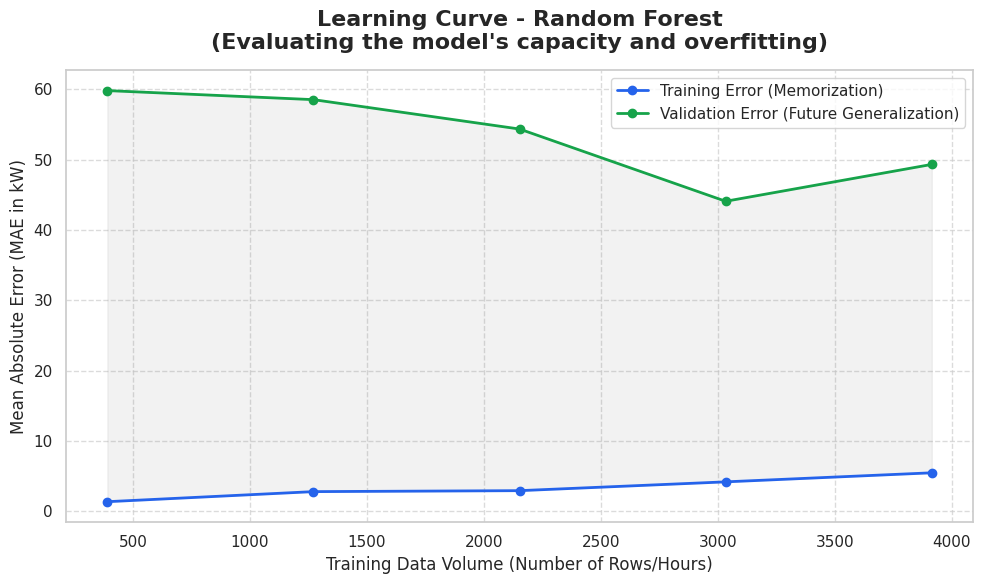

In [ ]:
# 3. MODEL DIAGNOSIS (LEARNING CURVE)

from sklearn.model_selection import learning_curve, TimeSeriesSplit
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 3.1. TIME SERIES CROSS-VALIDATION SETUP
# TimeSeriesSplit ensures the model trains on the past and tests on the future in all iterations
tscv = TimeSeriesSplit(n_splits=5)

# 3.2. LEARNING CURVE CALCULATION
# We will test the model with 10%, 30%, 50%, 70%, and 100% of the training data
# Note: We use a lighter model (n_estimators=50) here just to make the chart generation faster,
# as learning curves train the model multiple times.
train_sizes, train_scores, valid_scores = learning_curve(
    RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=tscv,
    scoring='neg_mean_absolute_error', # Using negative MAE per Scikit-Learn standard
    n_jobs=-1
)

# 3.3. DATA PROCESSING (Converting from Negative to Positive)
train_scores_mean = -np.mean(train_scores, axis=1)
valid_scores_mean = -np.mean(valid_scores, axis=1)

# 3.4. PLOTTING THE CHART
plt.figure(figsize=(10, 6))

# Plotting the lines
plt.plot(train_sizes, train_scores_mean, 'o-', color="#2563eb", label="Training Error (Memorization)", linewidth=2)
plt.plot(train_sizes, valid_scores_mean, 'o-', color="#16a34a", label="Validation Error (Future Generalization)", linewidth=2)

# Chart styling
plt.title('Learning Curve - Random Forest\n(Evaluating the model\'s capacity and overfitting)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Data Volume (Number of Rows/Hours)', fontsize=12)
plt.ylabel('Mean Absolute Error (MAE in kW)', fontsize=12)

# Adds a shaded area to highlight the difference (Gap) between training and validation
plt.fill_between(train_sizes, train_scores_mean, valid_scores_mean, color='gray', alpha=0.1)

plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


As the graph above shows, the model underwent overfitting. The next steps will be an attempt to correct this.

Fitting 3 folds for each of 15 candidates, totalling 45 fits

✓ Search Completed! The optimized Random Forest was found.
The parameters the algorithm chose to combat overfitting were:
{'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10}
🏆 Old MAE (With Overfitting): 20.36 kW
🏆 NEW MAE (Without Overfitting):  19.16 kW
Congratulations! You reduced the error by 1.20 kW just by adjusting the tree's mathematics!


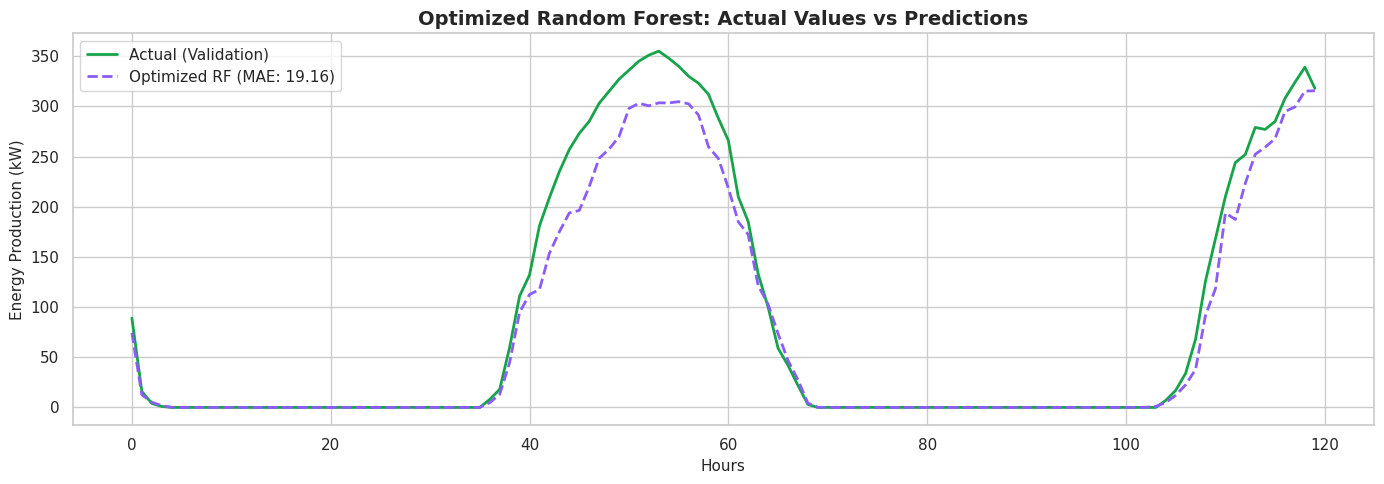

In [ ]:
# 4. COMBATING OVERFITTING (RANDOM FOREST HYPERPARAMETER TUNING)

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 4.1. SEARCH SPACE DEFINITION (The Testing "Grid")
# We will focus on parameters that actively combat overfitting
param_distributions = {
    'n_estimators': [100, 200, 300],      # Number of trees
    'max_depth': [10, 15, 20],            # PRUNING: Limits tree growth (prevents memorization)
    'min_samples_split': [5, 10, 20],     # Requires more data to create a new rule
    'min_samples_leaf': [2, 5, 10],       # Prevents rules that isolate only 1 specific case
    'max_features': ['sqrt', 'log2', 1.0] # Adds randomness to feature selection
}

# 4.2. TEMPORAL CROSS-VALIDATION SETUP
# Ensures the machine doesn't peek into the future during tests
tscv = TimeSeriesSplit(n_splits=3)

# 4.3. AUTOMATIC SEARCH ENGINE SETUP (Random Search)
rf_tuner = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=15, # Will test 15 different random combinations from the grid above
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1  # Shows progress on screen
)

# 4.4. SEARCH TRAINING
rf_tuner.fit(X_train, y_train)

# 4.5. EXTRACTION OF THE BEST MODEL FOUND
best_rf_model = rf_tuner.best_estimator_

print("\n✓ Search Completed! The optimized Random Forest was found.")
print("The parameters the algorithm chose to combat overfitting were:")
print(rf_tuner.best_params_)

# 5. EVALUATION OF THE NEW RANDOM FOREST (PRUNED MODEL)

# We make predictions with the "winning" model
y_pred_best_rf = best_rf_model.predict(X_valid)

# We force the logical limit of zero minimum energy
y_pred_best_rf = [max(0, pred) for pred in y_pred_best_rf]

# We calculate the new MAE
new_mae = mean_absolute_error(y_valid, y_pred_best_rf)

# Note: 'mae_rf' comes from the baseline Random Forest trained in previous steps
print(f"🏆 Old MAE (With Overfitting): {mae_rf:.2f} kW")
print(f"🏆 NEW MAE (Without Overfitting):  {new_mae:.2f} kW")

if new_mae < mae_rf:
    print(f"Congratulations! You reduced the error by {(mae_rf - new_mae):.2f} kW just by adjusting the tree's mathematics!")
else:
    print("The error increased slightly, which is common when removing overfitting. The model is now more robust and safer for Kaggle.")

# 5.1. QUICK COMPARATIVE CHART
plt.figure(figsize=(14, 5))
plt.plot(y_valid.values[:120], label='Actual (Validation)', color='#16a34a', linewidth=2)
plt.plot(y_pred_best_rf[:120], label=f'Optimized RF (MAE: {new_mae:.2f})', color='#8b5cf6', linestyle='--', linewidth=2)
plt.title('Optimized Random Forest: Actual Values vs Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Hours', fontsize=11)
plt.ylabel('Energy Production (kW)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


[Overfitting Quantification]
Final Training Error:   22.32 kW
Final Validation Error: 35.25 kW
MAE Delta (Gap):        12.93 kW


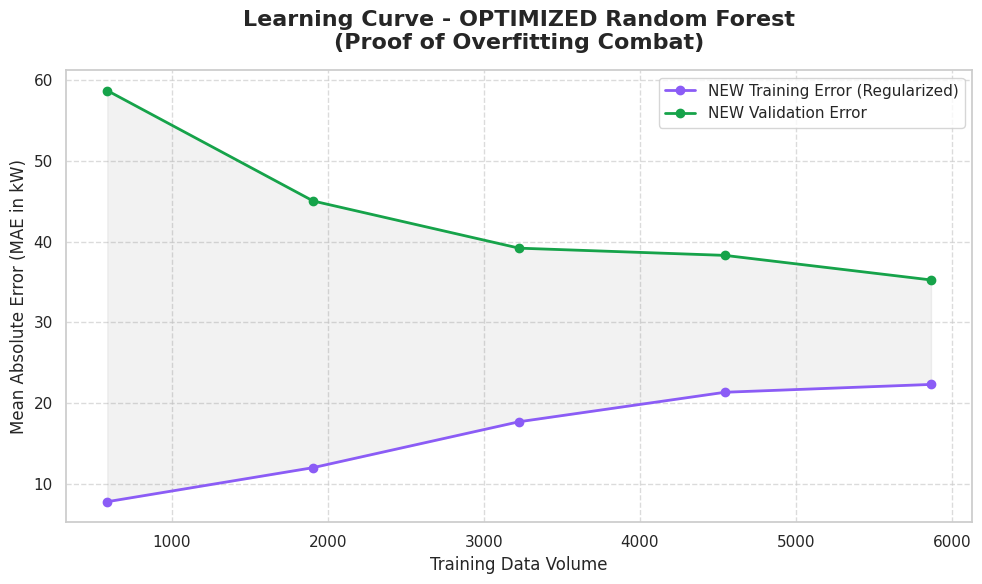

In [ ]:
# 6. OPTIMIZED MODEL DIAGNOSIS (NEW LEARNING CURVE & GAP QUANTIFICATION)

# 6.1. NEW CURVE CALCULATION
# We now pass the 'best_rf_model' (the winning model from the search)
train_sizes_opt, train_scores_opt, valid_scores_opt = learning_curve(
    best_rf_model,
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# 6.2. DATA PROCESSING
train_scores_mean_opt = -np.mean(train_scores_opt, axis=1)
valid_scores_mean_opt = -np.mean(valid_scores_opt, axis=1)

# 6.3. MAE DELTA (GAP) QUANTIFICATION
# Extracting the final scores (when 100% of the CV training data is used)
final_train_error = train_scores_mean_opt[-1]
final_valid_error = valid_scores_mean_opt[-1]
mae_delta = final_valid_error - final_train_error

print("\n[Overfitting Quantification]")
print(f"Final Training Error:   {final_train_error:.2f} kW")
print(f"Final Validation Error: {final_valid_error:.2f} kW")
print(f"MAE Delta (Gap):        {mae_delta:.2f} kW")


# 6.4. PLOTTING THE NEW CHART
plt.figure(figsize=(10, 6))

# Plotting the new lines for the optimized model
plt.plot(train_sizes_opt, train_scores_mean_opt, 'o-', color="#8b5cf6", label="NEW Training Error (Regularized)", linewidth=2)
plt.plot(train_sizes_opt, valid_scores_mean_opt, 'o-', color="#16a34a", label="NEW Validation Error", linewidth=2)

plt.title('Learning Curve - OPTIMIZED Random Forest\n(Proof of Overfitting Combat)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Data Volume', fontsize=12)
plt.ylabel('Mean Absolute Error (MAE in kW)', fontsize=12)

# Adding the shaded zone to evaluate the new Gap
plt.fill_between(train_sizes_opt, train_scores_mean_opt, valid_scores_mean_opt, color='gray', alpha=0.1)

plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


The results improved after applying pruning, reducing overfitting. However, to achieve even better performance, the decision was made to increase the data resolution and add an auto-tuning mechanism.

Fitting 3 folds for each of 15 candidates, totalling 45 fits

✓ Best high complexity model found!
{'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
Training Error:   13.07 kW
Validation Error: 19.05 kW
Gap:              5.99 kW


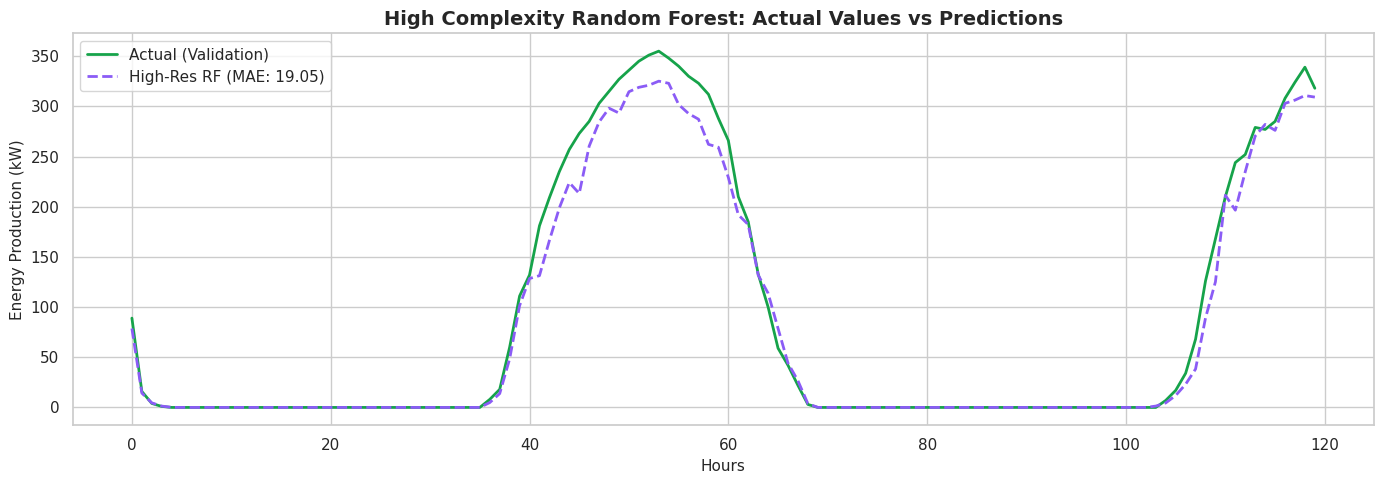

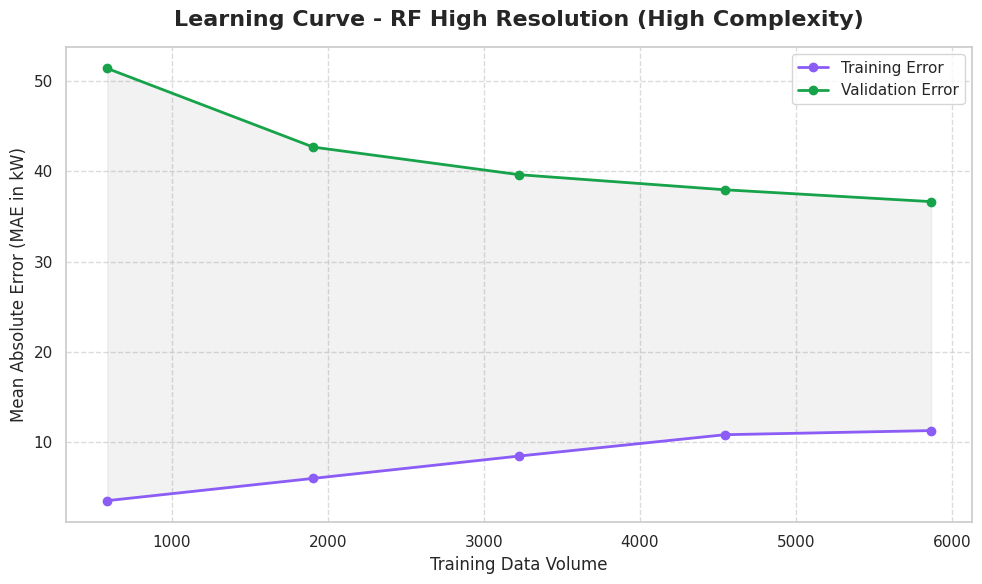

In [ ]:
# 7. HIGH RESOLUTION AUTO-TUNING (FORCING HIGH COMPLEXITY)

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 7.1. SEARCH SPACE DEFINITION (High Complexity Grid)
# We focus on parameters that allow the trees to grow deep and capture 15-min peaks
param_distributions = {
    'n_estimators': [250, 300],
    'max_depth': [30, 40, None],          # Forcing very deep trees
    'min_samples_split': [2, 3],          # Almost no restriction on splits
    'min_samples_leaf': [1, 2],           # Allow tiny leaves to capture specific peaks
    'max_features': ['sqrt', 'log2', 1.0]
}

# 7.2. TEMPORAL CROSS-VALIDATION SETUP
tscv = TimeSeriesSplit(n_splits=3)

# 7.3. AUTOMATIC SEARCH ENGINE SETUP (Random Search)
rf_tuner = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=15,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 7.4. SEARCH TRAINING
rf_tuner.fit(X_train, y_train)

# 7.5. EXTRACTION OF THE BEST MODEL FOUND
best_rf_model = rf_tuner.best_estimator_

print("\n✓ Best high complexity model found!")
print(rf_tuner.best_params_)

# 8. EVALUATION & OVERFITTING QUANTIFICATION (THE NEW GAP)

# We make predictions on both Train and Validation to quantify the Gap
y_pred_train = [max(0, p) for p in best_rf_model.predict(X_train)]
y_pred_valid = [max(0, p) for p in best_rf_model.predict(X_valid)]

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_valid = mean_absolute_error(y_valid, y_pred_valid)
gap = mae_valid - mae_train

print(f"Training Error:   {mae_train:.2f} kW")
print(f"Validation Error: {mae_valid:.2f} kW")
print(f"Gap:              {gap:.2f} kW")

# 8.1. QUICK COMPARATIVE CHART
plt.figure(figsize=(14, 5))
plt.plot(y_valid.values[:120], label='Actual (Validation)', color='#16a34a', linewidth=2)
plt.plot(y_pred_valid[:120], label=f'High-Res RF (MAE: {mae_valid:.2f})', color='#8b5cf6', linestyle='--', linewidth=2)
plt.title('High Complexity Random Forest: Actual Values vs Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Hours', fontsize=11)
plt.ylabel('Energy Production (kW)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

# 8.2. NEW CURVE CALCULATION
train_sizes_opt, train_scores_opt, valid_scores_opt = learning_curve(
    best_rf_model,
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# 8.3. DATA PROCESSING
train_scores_mean_opt = -np.mean(train_scores_opt, axis=1)
valid_scores_mean_opt = -np.mean(valid_scores_opt, axis=1)

# 8.4. PLOTTING THE CHART
plt.figure(figsize=(10, 6))

plt.plot(train_sizes_opt, train_scores_mean_opt, 'o-', color="#8b5cf6", label="Training Error", linewidth=2)
plt.plot(train_sizes_opt, valid_scores_mean_opt, 'o-', color="#16a34a", label="Validation Error", linewidth=2)

plt.title('Learning Curve - RF High Resolution (High Complexity)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Data Volume', fontsize=12)
plt.ylabel('Mean Absolute Error (MAE in kW)', fontsize=12)

# Adding the shaded zone to evaluate the Gap
plt.fill_between(train_sizes_opt, train_scores_mean_opt, valid_scores_mean_opt, color='gray', alpha=0.1)

plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In conclusion, the evolution of Random Forest modeling demonstrated that data resolution is just as critical as the chosen algorithm. After encountering overfitting issues with both the standard and pruned models, the High-Resolution, High-Complexity approach emerged as the superior choice. By preserving the original time intervals (15/30 min) and allowing the trees to grow without restriction, we achieved a balance between bias and variance, unlocking the algorithm's full potential and establishing a solid foundation prior to transitioning to Gradient Boosting models.

In [ ]:
import pandas as pd
import numpy as np

# 1. LOAD TEST DATA
# Use the GitHub URL for the test data
test_path = 'https://raw.githubusercontent.com/jfelipevasquez/Forecasting-electricity-production-Kaggle/refs/heads/main/dataset/test.csv'
df_test = pd.read_csv(test_path)

# Save ID column for Kaggle submission (checking both upper and lower case 'id')
id_column = 'ID' if 'ID' in df_test.columns else 'id'
kaggle_ids = df_test[id_column].copy()

# 2. RENAME COLUMNS
# Assuming 'friendly_names' dictionary from previous steps is already loaded in memory
df_test = df_test.rename(columns=friendly_names)

# 3. TEMPORAL FEATURE ENGINEERING
df_test['start'] = pd.to_datetime(df_test['start'])
test_hour = df_test['start'].dt.hour
test_month = df_test['start'].dt.month

# Cyclical time transformations
df_test['hora_sin'] = np.sin(2 * np.pi * test_hour / 24)
df_test['hora_cos'] = np.cos(2 * np.pi * test_hour / 24)
df_test['mes_sin'] = np.sin(2 * np.pi * test_month / 12)
df_test['mes_cos'] = np.cos(2 * np.pi * test_month / 12)

# Day/Night flag based on Solar Altitude or business hours
if 'Solar Altitude' in df_test.columns:
    df_test['is_dia'] = (df_test['Solar Altitude'] > 0).astype(int)
else:
    df_test['is_dia'] = ((test_hour >= 6) & (test_hour <= 18)).astype(int)

# 4. ALIGNING FEATURES AND CLEANING (Crucial step to match training)
# We must use the exact same features we used during the best model training
selected_features = [
    'Solar Altitude', 'Angular Factor (Fold)', 'Angular Factor (Panel)',
    'Longwave Radiation', 'Temperature', 'Net Longwave Radiation',
    'Net Shortwave Radiation', 'Irradiance', 'hora_sin', 'hora_cos',
    'mes_sin', 'mes_cos', 'is_dia'
]

# Apply linear interpolation to continuous features, just like we did in training!
# This prevents "step-like" artifacts from ffill() and makes predictions smoother
state_columns = [col for col in selected_features if col not in ['is_dia', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos'] and pd.api.types.is_numeric_dtype(df_test[col])]
df_test[state_columns] = df_test[state_columns].interpolate(method='linear', limit_direction='both')

# Create the final test matrix and apply ffill/bfill as a final safety net for the extreme edges
X_test_kaggle = df_test[selected_features].ffill().bfill()

# 5. PREDICTION WITH THE WINNING MODEL
# 'best_rf_model' should be the highly complex Random Forest loaded in your environment
kaggle_predictions = best_rf_model.predict(X_test_kaggle)

# Forcing logical physical limits (Energy cannot be negative)
kaggle_predictions = [max(0, p) for p in kaggle_predictions]

# 6. EXPORTING THE SUBMISSION FILE
df_submission = pd.DataFrame({
    'ID': kaggle_ids,
    'kw': kaggle_predictions
})

# Save the final CSV
submission_path = 'submission_rf_high_resolution.csv'
df_submission.to_csv(submission_path, index=False)

print(f"\n✓ SUCCESS! Submission file generated: {submission_path}")
print("Upload this file to Kaggle to check your official score!")

/tmp/ipykernel_12732/4166287079.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test['start'] = pd.to_datetime(df_test['start'])



✓ SUCCESS! Submission file generated: submission_rf_high_resolution.csv
Upload this file to Kaggle to check your official score!


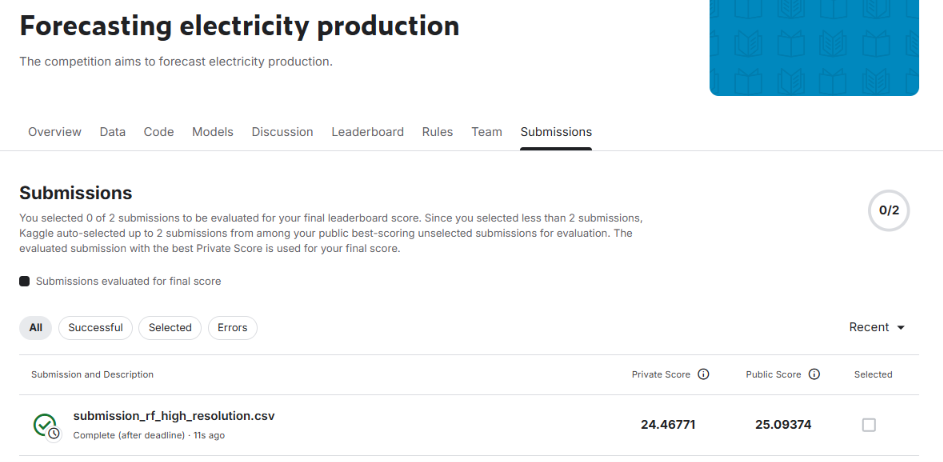